# Boolsche Serien
Durch Vergleichsoperatoren lassen sich Boolsche Serien erstellen, wie man das schon von Numpy kennt. Diese Serien lassen sich in einem weiteren Schritt für Filteroperationen nutzen.

## Beispiel-Datei
Wir lesen als Übungsdatei die `netflix_titles.csv` - Datei ein, die alle Filme und Serien, die auf Netflix verfügbar sind (bzw. 2019 waren) abbildet.

### Untersuchen des Datensatzes
Bevor wir mit dem Filtern beginnen, wollen wir den Datensatz untersuchen:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/netflix_titles.csv")

# Sehen wir uns die ersten und letzten zwei Einträge an. 
display(df.head(2))
display(df.tail(2))


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [3]:
df.shape

(7787, 12)

In [4]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

#### eindeutige Werte einer Spalte bestimmen
mit `unique()` lassen sich alle Vorkommen eines Wertes in einer Spalte bestimmen. So gibt es in der Spalte `type` nur die beiden Werte `TV Show` und `Movie`. Das ist nur sinnvoll anzuwenden bei Kategorien oder diskreten Werten.

In [5]:
# unique auf Spalte

In [6]:
df.type.unique()

array(['TV Show', 'Movie'], dtype=object)

In [7]:
df.country.unique()

array(['Brazil', 'Mexico', 'Singapore', 'United States', 'Turkey',
       'Egypt', 'India', 'Poland, United States', 'Thailand', 'Nigeria',
       nan, 'Norway, Iceland, United States', 'United Kingdom', 'Japan',
       'South Korea', 'Italy', 'Canada', 'Indonesia', 'Romania', 'Spain',
       'Iceland', 'South Africa, Nigeria', 'France',
       'United States, South Africa', 'Portugal, Spain',
       'Hong Kong, China, Singapore', 'United States, Germany',
       'South Africa, China, United States', 'Argentina',
       'United States, France, Serbia', 'Germany',
       'Denmark, France, Poland', 'Poland', 'Kenya',
       'New Zealand, United Kingdom', 'Pakistan', 'Australia',
       'Australia, United States', 'Mexico, United States',
       'United States, China', 'China, Hong Kong', 'Taiwan',
       'United States, United Kingdom', 'France, South Korea, Japan',
       'United States, Canada', 'United Kingdom, United States',
       'Netherlands, Denmark, South Africa', 'Canada, Unit

#### Value Counts: Häufigkeiten zählen
mit `value_counts()` können wir die Häufigkeiten der vorkommen bestimmen. Das ist natürlich ebenso wie `unique` nur sinnvoll bei Kategorien oder diskreten Werten.

In [8]:
# Häufigkeit von Direktoren
df.director.value_counts()

director
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
                          ..
John Suits                 1
Ryan Koo                   1
Paul Greengrass            1
Swapnaneel Jayakar         1
Gilbert Chan               1
Name: count, Length: 4049, dtype: int64

<Axes: ylabel='count'>

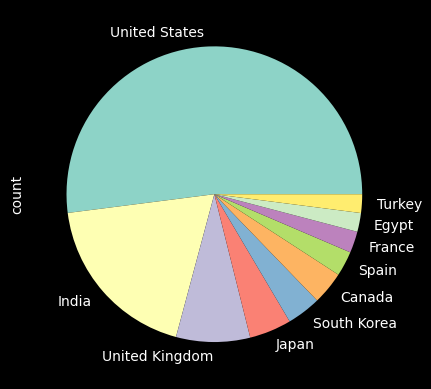

In [9]:
# Tortendiagramm der Länder
x = df.country.value_counts()[:10]
x.plot(kind="pie")

## Boolsche Serie erstellen
Für das erstellen einer Boolschen Serie, d.h. einer Spalte mit Wahrheitswerten, stehen uns neben den arithmetischen Vergleichsoperatoren >, <, >=, <= auch boolsche Operatoren & (UND), | (ODER) und ! (NOT) zur Verfüfung.

eine boolsche Serie enthält genausoviele Einträge wie die Ausgangsserie. An den Stellen, wo die Bedingung zutrifft, steht ein True, andernfalls ein False.

### Beispiel: boolsche Serie mit equals
eine boolsche Serie mit allen Werken aus Australien.

In [10]:
# eine boolsche Serie mit allen Werken aus Australien. Shape ausgeben
colombian_titles = (df.country == "Colombia")
colombian_titles.shape

(7787,)

### Beispiel: kleiner gleich

In [11]:
# Title kleiner als 2020
past_titles = df.release_year < 2020
print(past_titles)

0       False
1        True
2        True
3        True
4        True
        ...  
7782     True
7783     True
7784     True
7785     True
7786     True
Name: release_year, Length: 7787, dtype: bool


### Beispiel: kleiner gleich UND Bedingung
Im folgenden Beipsiel wird eine Serie erstellt mit allen Werden vor 2019 dir NUR aus dem Land Australien stammen. Das Feature `country` ist nämlich in den Ausgangsdaten eine kommaseparierte Liste.

In [12]:
# Australische Title jünger als 2020
steven_sp_2017 = (df.director == "Steven Spielberg") & (df.release_year == 2017)
print(steven_sp_2017)

0       False
1       False
2       False
3       False
4       False
        ...  
7782    False
7783    False
7784    False
7785    False
7786    False
Length: 7787, dtype: bool


### Beispiel: kleiner gleich UND Bedingung

In [13]:
# Stevens Spielberg Title vor dem Jahr 2017
steven_sp_2090 = (df.director == "Steven Spielberg") & (df.release_year <= 1990)
print(steven_sp_2090)

df[steven_sp_2090]


0       False
1       False
2       False
3       False
4       False
        ...  
7782    False
7783    False
7784    False
7785    False
7786    False
Length: 7787, dtype: bool


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2991,s2992,Movie,Indiana Jones and the Last Crusade,Steven Spielberg,"Harrison Ford, Sean Connery, Denholm Elliott, ...",United States,"January 1, 2019",1989,PG-13,127 min,"Action & Adventure, Children & Family Movies, ...","Accompanied by his father, Indiana Jones sets ..."
2992,s2993,Movie,Indiana Jones and the Raiders of the Lost Ark,Steven Spielberg,"Harrison Ford, Karen Allen, Paul Freeman, Rona...",United States,"January 1, 2019",1981,PG,116 min,"Action & Adventure, Children & Family Movies, ...",When Indiana Jones is hired by the government ...
2993,s2994,Movie,Indiana Jones and the Temple of Doom,Steven Spielberg,"Harrison Ford, Kate Capshaw, Amrish Puri, Rosh...",United States,"January 1, 2019",1984,PG,119 min,"Action & Adventure, Children & Family Movies, ...","Indiana Jones, his young sidekick and a spoile..."


# Datentyp-spezifische Zugriffsmethoden:
Es gibt in Pandas 4 datentyp-spezifische Zugriffsmethoden, sogenannte `Accessors`. wir unterscheiden zwischen folgenden Accessoren:

* str (für String-Operationen)
* dt (für Datums-Operationen)
* cat (für kategorische Operationen)
* sparse (für Datensparsame Verwaltung von Dataframes)

## String-Funktionen
Pandas bietet über den String-Zugriff `str` Zugriff auf vielfältige String-Methoden. Eine Übersicht aller findet sich in der Doku:

https://www.geeksforgeeks.org/top-10-string-methods-in-pandas/

In [14]:
type(df.country.str)

pandas.core.strings.accessor.StringMethods

### Beispiel: kleiner gleich ODER Bedingung mit Stringfunktion contains
Um den Inhalt bzw. das Vorkommen von Substrings zu prüfen, können wir mit dem String-Accessor `str` arbeiten. Im Beispiel alle Titel, die mit oder in Zusammenarbeit mit Australien erstellt wurden. Nachteil ist, dass diese Prüfung unzuverlässig ist. Ein Land namens `Australiana` würde ebenfalls matchen.

In [15]:
australian_titles = df.country.str.contains('Australia')
australian_titles.sum()

144

### Beispiel: Oder Bedingung mit startswith

In [16]:
se_ge_titles = df.director.str.startswith("Se") | df.director.str.startswith("Ge")
se_ge_titles.sum()

np.int64(68)

In [17]:
se_ge_titles.memory_usage() / 1024

7.7333984375

## Beispiel: Intervall
mit `between` prüfen, ob Wert in einem gewissen Wertebereich liegt. Über den Parameter `inclusive` lässt sich noch Steuern, ob Start und Entwerte berücksichtig werden sollen. 

`inclusive{“both”, “neither”, “left”, “right”}`

In [18]:
titles_2014_2018 = df.release_year.between(2014, 2018, inclusive="both")
titles_2014_2018

0       False
1        True
2       False
3       False
4       False
        ...  
7782    False
7783     True
7784    False
7785    False
7786    False
Name: release_year, Length: 7787, dtype: bool

### Sparse Data Accessor-Beispiel
mit dem `Sparse`-Data Accessor lassen sich Series und Dataframes speicherreduziert speichern. Im Falle von sehr vielen und sehr großen Datenmengen macht diese Operation Sinn.

In [19]:
## sparse data
se_ge_titles = se_ge_titles.astype("Sparse[bool]")
se_ge_titles.memory_usage(), se_ge_titles.shape

(472, (7787,))

## Aufgabe: Netflix-Daten analysieren

## Aufgaben
### Erstes Slicing
- Wähle nur die Spalten `title`, `type`, `director`, `country`, `release_year`, `rating`, `duration` und `listed_in` aus.
- Speichere das Ergebnis als `df_filtered`.

### Boolean-Filterung
- Erstelle einen neuen DataFrame `df_movies`, der nur **Filme (`type == "Movie"`)** enthält.
- Erstelle einen weiteren DataFrame `df_series`, der nur **Serien (`type == "TV Show"`)** enthält.

### Datenbereinigung und Umwandlung (Movies)
- Entferne alle Zeilen aus `df_movies`, bei denen `duration` fehlt.
- Wandle die `duration`-Spalte für Filme um, sodass nur die **Anzahl der Minuten als `int`** gespeichert wird.
  - Beispiel: `"90 min"` → `90`. Andere Angaben ohne min sollen ignoriert werden (leer)
- Speichere das bereinigte Ergebnis als `df_movies_cleaned`.

### `apply()`-Funktion verwenden
- Füge in `df_movies_cleaned` eine neue Spalte `"old_or_new"` hinzu:
  - Falls der Film vor **2000** erschienen ist, soll `"Old"` eingetragen werden.
  - Falls er ab **2000** erschienen ist, soll `"New"` eingetragen werden.

---

## Erwartetes Ergebnis

| title                 | type  | director     | country       | release_year | rating | duration | listed_in       | old_or_new |
|-----------------------|------|-------------|--------------|--------------|--------|----------|----------------|------------|
| The Irishman         | Movie | Martin Scorsese | USA          | 2019         | R      | 209      | Drama          | New        |
| The Godfather        | Movie | Francis Ford Coppola | USA | 1972         | R      | 175      | Crime, Drama   | Old        |
| Inception           | Movie | Christopher Nolan | USA | 2010         | PG-13  | 148      | Sci-Fi, Action | New        |
| Pulp Fiction        | Movie | Quentin Tarantino | USA | 1994         | R      | 154      | Crime, Drama   | Old        |

---

## Bonus-Aufgabe (optional)
1. Finde heraus, wie viele Filme **pro Altersfreigabe (`rating`)** existieren.
2. Erstelle eine **sortierte Liste** mit den Ländern, die die meisten Filme produziert haben.

Happy Coding!


In [25]:
# Erstes Slicing
df_filtered = df[["title", "type", "director", "country", "release_year", "rating", "duration", "listed_in"]]

# Boolean-Filterung
df_movies = df_filtered[df_filtered["type"] == "Movie"].copy()
df_series = df_filtered[df_filtered["type"] == "TV Show"].copy()

display(df_movies.head())
# Datenbereinigung: Entferne Filme mit fehlender Dauer
df_movies_cleaned = df_movies.dropna(subset=["duration"]).copy()

# Erstmal Maske holen mit allen durations, die min beinhalten
mask = df_movies_cleaned["duration"].str.contains("min", na=False)

# Wandle "duration" für Filme um (entferne "min" und konvertiere zu int)
df_movies_cleaned["duration"] = (
    df_movies_cleaned["duration"]
        .str.extract(r"(\d+)")[0]
        .astype(int)
)

# Neue Spalte "old_or_new" ohne apply() hinzufügen
df_movies_cleaned["old_or_new"] = np.where(
    df_movies_cleaned["release_year"] < 2000,
    "Old",
    "New"
)

# Ergebnis anzeigen
display(df_movies_cleaned.head())

print(" --------- " * 5)

# Bonus-Aufgabe 1: Anzahl der Filme pro Altersfreigabe
rating_counts = df_movies_cleaned["rating"].value_counts()
print("Anzahl der Filme pro Altersfreigabe:\n", rating_counts)

# Bonus-Aufgabe 2: Länder mit den meisten Filmen
country_counts = df_movies_cleaned["country"].value_counts()
print("Länder mit den meisten Filmen:\n", country_counts)

,title,type,director,country,release_year,rating,duration,listed_in
1,7:19,Movie,Jorge Michel Grau,Mexico,2016,TV-MA,93 min,"Dramas, International Movies"
2,23:59,Movie,Gilbert Chan,Singapore,2011,R,78 min,"Horror Movies, International Movies"
3,9,Movie,Shane Acker,United States,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi..."
4,21,Movie,Robert Luketic,United States,2008,PG-13,123 min,Dramas
6,122,Movie,Yasir Al Yasiri,Egypt,2019,TV-MA,95 min,"Horror Movies, International Movies"


,title,type,director,country,release_year,rating,duration,listed_in,old_or_new
1,7:19,Movie,Jorge Michel Grau,Mexico,2016,TV-MA,93,"Dramas, International Movies",New
2,23:59,Movie,Gilbert Chan,Singapore,2011,R,78,"Horror Movies, International Movies",New
3,9,Movie,Shane Acker,United States,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...",New
4,21,Movie,Robert Luketic,United States,2008,PG-13,123,Dramas,New
6,122,Movie,Yasir Al Yasiri,Egypt,2019,TV-MA,95,"Horror Movies, International Movies",New


 ---------  ---------  ---------  ---------  --------- 
Anzahl der Filme pro Altersfreigabe:
 rating
TV-MA       1845
TV-14       1272
R            663
TV-PG        505
PG-13        386
PG           247
TV-Y         117
TV-G         111
TV-Y7         95
NR            79
G             39
TV-Y7-FV       5
UR             5
NC-17          3
Name: count, dtype: int64
Länder mit den meisten Filmen:
 country
United States                             1850
India                                      852
United Kingdom                             193
Canada                                     118
Egypt                                       89
                                          ... 
Egypt, Austria, United States                1
Russia, Spain                                1
Croatia, Slovenia, Serbia, Montenegro        1
United Arab Emirates, Jordan                 1
Belgium, United Kingdom, United States       1
Name: count, Length: 590, dtype: int64
